<h1> Data set: Skin Cancer MNIST: HAM10000

This is an analysis of a large collection of multi-source dermatoscopic images of pigmented lesions

The final dataset consists of 10015 dermatoscopic images.

Cases include a representative collection of all important diagnostic categories in the realm of pigmented lesions:
- **akiec**: Actinic keratoses and intraepithelial carcinoma / Bowen's disease
- **bcc**: Basal cell carcinoma  
- **bkl**: benign keratosis-like lesions (solar lentigines / seborrheic keratoses and lichen-planus like keratoses)
- **df**: Dermatofibroma (df),
- **mel**: Melanoma (mel),
- **nv**: Melanocytic nevi (nv) and
- **vasc**: Vascular lesions (angiomas, angiokeratomas, pyogenic granulomas and hemorrhage, vasc).

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
# Imports

import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, models, optimizers, metrics
from tensorflow.keras import layers, Model, Input
from keras.applications.efficientnet import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [12]:
print(os.getcwd())

/content


In [13]:


print(os.listdir("."))

['.config', 'drive', 'sample_data']


<h2>1. Data upload


In [15]:
# Paths to metadata set and image folders
data_dir = "/content/drive/MyDrive/Data"

metadata_path = f"{data_dir}/HAM10000_metadata.csv"
# Image folders
img_dir_1 = f"{data_dir}/HAM10000_images_part_1"
img_dir_2 = f"{data_dir}/HAM10000_images_part_2"


In [16]:
print("\n--- Starting Data Preparation ---")
ds = pd.read_csv(metadata_path)


--- Starting Data Preparation ---


In [17]:
ds.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [18]:
def find_relative_image_path(image_id):
    filename = f"{image_id}.jpg"
    path1 = os.path.join(img_dir_1, filename)
    path2 = os.path.join(img_dir_2, filename)

    if os.path.exists(path1):
        return path1
    if os.path.exists(path2):
        return path2

    print(f"⚠️ Image not found: {filename}")
    return None

In [19]:
# --- Build path column ---
ds["img_path"] = ds["image_id"].apply(find_relative_image_path)

print("✅ Image path column added")
ds.head()



✅ Image path column added


,lesion_id,image_id,dx,dx_type,age,sex,localization,img_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/drive/MyDrive/Data/HAM10000_images_pa...


In [20]:
# Paths to the data
#METADATA_CSV = "HAM10000_metadata.csv"
#IMAGES_DIR_1 = "HAM10000_images_part_1"
#IMAGES_DIR_2 = "HAM10000_images_part_2"

model_timings = []

# Parameters
IMG_SIZE = 224          #  input size for ResNet/DenseNet (square)
BATCH_SIZE = 32
SEED = 42
EPOCHS_SIMPLE = 15
EPOCHS_TRANSFER = 15

AUTOTUNE = tf.data.AUTOTUNE

# Fixing the seeds for some reproducibility
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# Full names dictionary
FULL_DX_NAMES = {
    "akiec": "Bowen's disease",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis-like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

<h2> 2. Cleaning Data

In [21]:
#Loading the CSV
print("Size metadata csv :", ds.shape)


# Columns needed for the MVP
#cols_mvp = ["image_id", "lesion_id", "dx"]
#df = meta[cols_mvp].copy()

# Removing any duplicates in image_id
ds = ds.drop_duplicates(subset="image_id").reset_index(drop=True)


display(ds.head())

# Checking for missing values
print("\n Missing values :")
print(ds.isna().sum())


Size metadata csv : (10015, 8)


,lesion_id,image_id,dx,dx_type,age,sex,localization,img_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/drive/MyDrive/Data/HAM10000_images_pa...



 Missing values :
lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
img_path         0
dtype: int64


In [22]:
# ------------------------------------------------------------------------------
# Checking missing values in age column
# ------------------------------------------------------------------------------
missing_age = ds['age'].isna().sum()
print("Number of rows with missing ages:", missing_age)

# ------------------------------------------------------------------------------
# Check how many 'unknown' in sex
# ------------------------------------------------------------------------------
num_unknown_sex = (ds['sex'] == 'unknown').sum()
print("Number of 'unknown' in sex:", num_unknown_sex)

# ------------------------------------------------------------------------------
# Check how many 'unknown' in localization
# ------------------------------------------------------------------------------
num_unknown_localization = (ds['localization'] == 'unknown').sum()
print("Number of 'unknown' in localization:", num_unknown_localization)

Number of rows with missing ages: 57
Number of 'unknown' in sex: 57
Number of 'unknown' in localization: 234


In [23]:

# ------------------------------------------------------------------------------
# Checking the rows with missing age
# ------------------------------------------------------------------------------
ds[ds['age'].isna()]

,lesion_id,image_id,dx,dx_type,age,sex,localization,img_path
968,HAM_0001186,ISIC_0033391,bkl,consensus,NaN,unknown,unknown,/content/drive/MyDrive/Data/HAM10000_images_pa...
969,HAM_0002660,ISIC_0033750,bkl,consensus,NaN,unknown,unknown,/content/drive/MyDrive/Data/HAM10000_images_pa...
970,HAM_0000372,ISIC_0033685,bkl,consensus,NaN,unknown,unknown,/content/drive/MyDrive/Data/HAM10000_images_pa...
971,HAM_0000948,ISIC_0033631,bkl,consensus,NaN,unknown,unknown,/content/drive/MyDrive/Data/HAM10000_images_pa...
972,HAM_0000983,ISIC_0033490,bkl,consensus,NaN,unknown,unknown,/content/drive/MyDrive/Data/HAM10000_images_pa...
973,HAM_0007281,ISIC_0034283,bkl,consensus,NaN,unknown,unknown,/content/drive/MyDrive/Data/HAM10000_images_pa...
974,HAM_0001561,ISIC_0032740,bkl,consensus,NaN,unknown,unknown,/content/drive/MyDrive/Data/HAM10000_images_pa...
975,HAM_0000825,ISIC_0034186,bkl,consensus,NaN,unknown,unknown,/content/drive/MyDrive/Data/HAM10000_images_pa...
977,HAM_0006074,ISIC_0034252,bkl,consensus,NaN,unknown,unknown,/content/drive/MyDrive/Data/HAM10000_images_pa...
978,HAM_0006074,ISIC_0033829,bkl,consensus,NaN,unknown,unknown,/content/drive/MyDrive/Data/HAM10000_images_pa...


One can see that there are many rows with age = NaN and at the same time location/sex = unknown.

Find rows where all three conditions happen simultaneously:
- age is NaN
- sex is "unknown"
- localization is "unknown"

Drop the rows where all three conditions happen simultaneously

In [24]:
#-------------------------------------------------------------------------------
# Filter rows where all three conditions are met
#-------------------------------------------------------------------------------

# Condition for rows to drop
condition_all_three = (
    ds['age'].isna() &
    (ds['sex'] == 'unknown') &
    (ds['localization'] == 'unknown')
)

# Number of rows to remove
removed_count = condition_all_three.sum()
print("Rows to remove (all 3 conditions):", removed_count)

# Remove them
ds_clean = ds[~condition_all_three].reset_index(drop=True)

print("\nShape after cleaning:", ds_clean.shape)

Rows to remove (all 3 conditions): 47

Shape after cleaning: (9968, 8)


In [25]:
# Missing values in age
remaining_age_nan = ds_clean['age'].isna().sum()
print("Remaining age NaN:", remaining_age_nan)

# “unknown” values in sex
remaining_sex_unknown = (ds_clean['sex'] == 'unknown').sum()
print("Remaining sex = 'unknown':", remaining_sex_unknown)

# “unknown” values in localization
remaining_loc_unknown = (ds_clean['localization'] == 'unknown').sum()
print("Remaining localization = 'unknown':", remaining_loc_unknown)


Remaining age NaN: 10
Remaining sex = 'unknown': 10
Remaining localization = 'unknown': 187


In [26]:
print("\n--- SUMMARY AFTER CLEANING ---")
print(f"Removed rows (all 3 conditions): {removed_count}")
print(f"Remaining age NaN: {remaining_age_nan}")
print(f"Remaining sex 'unknown': {remaining_sex_unknown}")
print(f"Remaining localization 'unknown': {remaining_loc_unknown}")


--- SUMMARY AFTER CLEANING ---
Removed rows (all 3 conditions): 47
Remaining age NaN: 10
Remaining sex 'unknown': 10
Remaining localization 'unknown': 187


<h2> 3. Filling Unknown/missing data

<h4>3.1. For age missing values

For skewed medical age distributions:
- mean is very sensitive to outliers
- median is robust and clinically appropriate

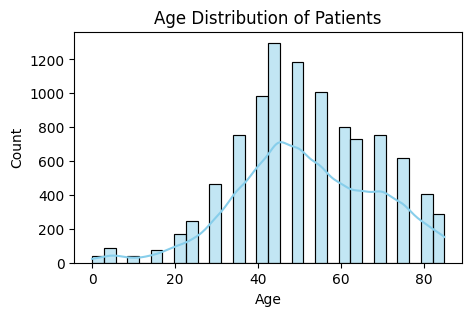

In [27]:
# Plot age distribution to check skewness
plt.figure(figsize=(5, 3))
sns.histplot(ds_clean['age'].dropna(), bins=30, kde=True, color='skyblue')
plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

In [28]:
# ----- 1. Impute age (skewed distribution → median) -----
ds_clean["age"] = ds_clean["age"].fillna(ds_clean["age"].median())

<h4> 3.2. Handling “unknown” in categorical columns (sex and location)

Strategy: Keep “unknown” as its own category

In [29]:
# ----- 2. Replace unknown in sex with its own category -----
ds_clean["sex"] = ds_clean["sex"].replace("unknown", "unk")

In [30]:
# ----- 3. Replace unknown in localization with its own category -----
ds_clean["localization"] = ds_clean["localization"].replace("unknown", "unk")

In [31]:
# Missing values in age
remaining_age_nan2 = ds_clean['age'].isna().sum()
print("Remaining age NaN after filling:", remaining_age_nan2)

# “unknown” values in sex
remaining_sex_unknown2 = (ds_clean['sex'] == 'unknown').sum()
print("Remaining sex after filling = 'unknown':", remaining_sex_unknown2)

# “unknown” values in localization
remaining_loc_unknown2 = (ds_clean['localization'] == 'unknown').sum()
print("Remaining localization after filling = 'unknown':", remaining_loc_unknown2)

Remaining age NaN after filling: 0
Remaining sex after filling = 'unknown': 0
Remaining localization after filling = 'unknown': 0


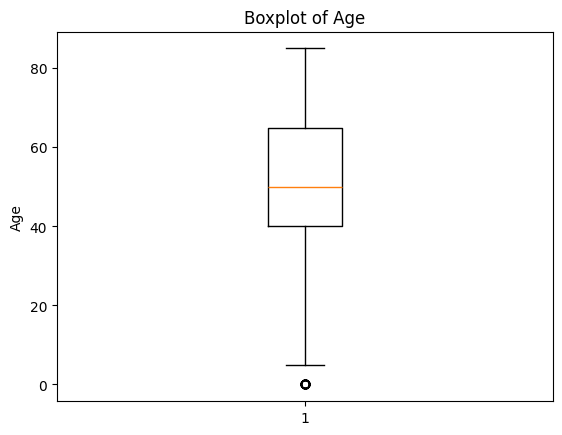

In [32]:
# ------------------------------------------------------------------------------
# Checking outliers
# ------------------------------------------------------------------------------
plt.boxplot(ds_clean['age'].dropna())
plt.title("Boxplot of Age")
plt.ylabel("Age")
plt.show()

<h2>4. Label encoding of the diagnostic categories (dx)

In [33]:
# ------------------------------------------------------------------------------
# Label encoding
# ------------------------------------------------------------------------------
class_names = sorted(ds_clean["dx"].unique())
class_to_index = {name: idx for idx, name in enumerate(class_names)}
index_to_class = {idx: name for name, idx in class_to_index.items()}

ds_clean["label"] = ds_clean["dx"].map(class_to_index)

num_classes = len(class_names)
print("Classes :", class_names)
print("Class names:", num_classes)

display(ds_clean.head())


Classes : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Class names: 7


,lesion_id,image_id,dx,dx_type,age,sex,localization,img_path,label
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...,2
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...,2
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...,2
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...,2
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/content/drive/MyDrive/Data/HAM10000_images_pa...,2


In [34]:
print(ds_clean.shape)
print(ds_clean["lesion_id"].isna().sum())
print(ds_clean["lesion_id"].nunique())
print(ds_clean["lesion_id"].head())

(9968, 9)
0
7424
0    HAM_0000118
1    HAM_0000118
2    HAM_0002730
3    HAM_0002730
4    HAM_0001466
Name: lesion_id, dtype: object


In [35]:
ds_clean = ds_clean.drop(columns=["dx_type"], errors="ignore")

In [36]:
ds_clean

,lesion_id,image_id,dx,age,sex,localization,img_path,label
0,HAM_0000118,ISIC_0027419,bkl,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...,2
1,HAM_0000118,ISIC_0025030,bkl,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...,2
2,HAM_0002730,ISIC_0026769,bkl,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...,2
3,HAM_0002730,ISIC_0025661,bkl,80.0,male,scalp,/content/drive/MyDrive/Data/HAM10000_images_pa...,2
4,HAM_0001466,ISIC_0031633,bkl,75.0,male,ear,/content/drive/MyDrive/Data/HAM10000_images_pa...,2
...,...,...,...,...,...,...,...,...
9963,HAM_0002867,ISIC_0033084,akiec,40.0,male,abdomen,/content/drive/MyDrive/Data/HAM10000_images_pa...,0
9964,HAM_0002867,ISIC_0033550,akiec,40.0,male,abdomen,/content/drive/MyDrive/Data/HAM10000_images_pa...,0
9965,HAM_0002867,ISIC_0033536,akiec,40.0,male,abdomen,/content/drive/MyDrive/Data/HAM10000_images_pa...,0
9966,HAM_0000239,ISIC_0032854,akiec,80.0,male,face,/content/drive/MyDrive/Data/HAM10000_images_pa...,0


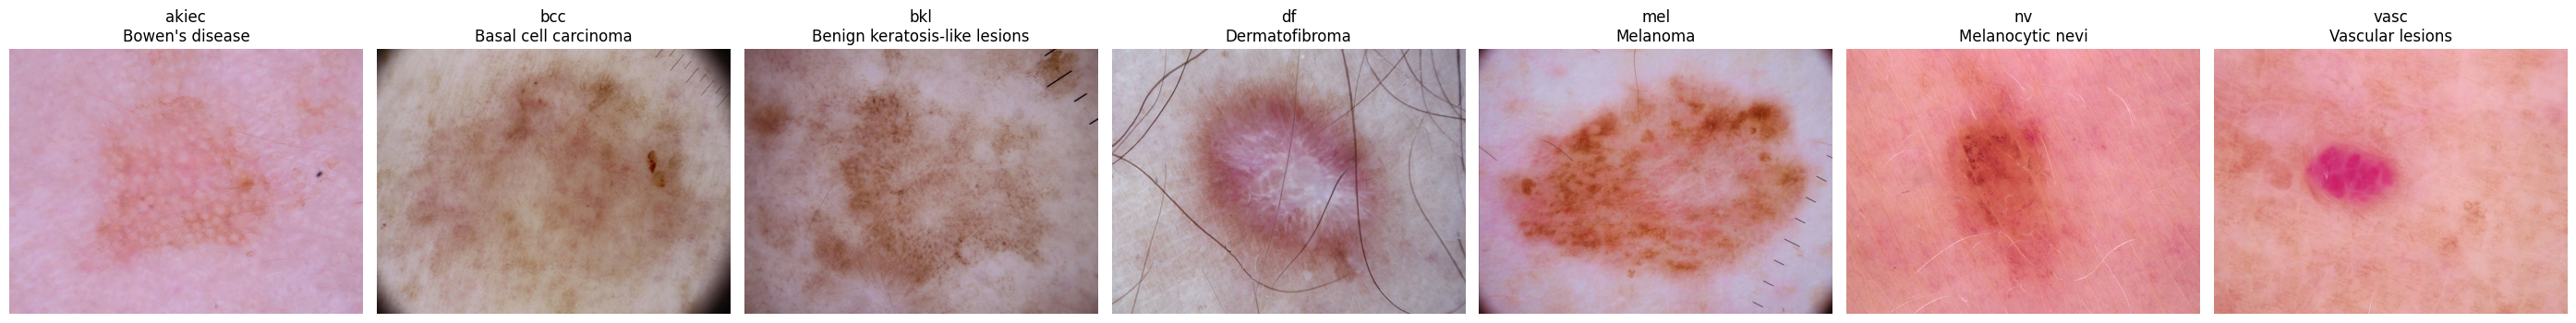

In [37]:
# ------------------------------------------------------------------------------
# Display one image per lesion type
# ------------------------------------------------------------------------------


def show_one_image_per_class(df, class_names, seed=SEED):
    plt.figure(figsize=(4 * len(class_names), 4))

    for i, cls in enumerate(class_names):
        sample = df[df["dx"] == cls].sample(1, random_state=seed)
        img_path = sample["img_path"].values[0]
        img = plt.imread(img_path)

        full_name = FULL_DX_NAMES.get(cls, "Unknown class")

        ax = plt.subplot(1, len(class_names), i + 1)
        plt.imshow(img)

        # Show abbreviation and full name
        plt.title(f"{cls}\n{full_name}")

        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Call the function
show_one_image_per_class(ds_clean, class_names)

<h2> 5. Train/val/test split by lesion_id

ds_clean into train, val, test

In [45]:
SEED = 42
num_classes = ds_clean["label"].nunique()

# Get unique lesions
lesion_df = ds_clean.groupby("lesion_id")["dx"].first().reset_index()

# Lesion-level split (never image-level!!)
train_lesions, temp_lesions = train_test_split(
    lesion_df, test_size=0.30, stratify=lesion_df["dx"], random_state=SEED
)

val_lesions, test_lesions = train_test_split(
    temp_lesions, test_size=0.50, stratify=temp_lesions["dx"], random_state=SEED
)

train_ids = set(train_lesions["lesion_id"])
val_ids   = set(val_lesions["lesion_id"])
test_ids  = set(test_lesions["lesion_id"])

def split_df(ds):
    train = ds[ds["lesion_id"].isin(train_ids)].copy()
    val   = ds[ds["lesion_id"].isin(val_ids)].copy()
    test  = ds[ds["lesion_id"].isin(test_ids)].copy()
    return train, val, test

train_df, val_df, test_df = split_df(ds_clean)

print('train_df',train_df.shape, 'val_df',val_df.shape, 'test',test_df.shape)


train_df (6963, 8) val_df (1481, 8) test (1524, 8)


<h2> 6. Oversample train_df only

In [46]:
def oversample_dataframe(df, label_col="dx", seed=SEED):
    class_counts = df[label_col].value_counts()
    max_count = class_counts.max()

    oversampled_dfs = [
        df_group.sample(max_count, replace=True, random_state=seed)
        for _, df_group in df.groupby(label_col)
    ]

    return (
        pd.concat(oversampled_dfs)
        .sample(frac=1.0, random_state=seed)
        .reset_index(drop=True)
    )

<h2> 7. Metadata Preparation

	•	AGE → scaled
	•	SEX → one-hot
	•	LOCATION → one-hot

In [47]:
meta_features = ["age", "sex", "localization"]

meta_preprocessor = ColumnTransformer([
    ("scale_age", StandardScaler(), ["age"]),
    ("encode_cat", OneHotEncoder(sparse_output=False), ["sex", "localization"])
])

Fit only train

In [48]:
# Fit only on TRAIN
meta_preprocessor.fit(train_df[meta_features])

ColumnTransformer(transformers=[('scale_age', StandardScaler(), ['age']),
                                ('encode_cat',
                                 OneHotEncoder(sparse_output=False),
                                 ['sex', 'localization'])])

Transform each split

In [49]:
train_meta = meta_preprocessor.transform(train_df[meta_features])
val_meta   = meta_preprocessor.transform(val_df[meta_features])
test_meta  = meta_preprocessor.transform(test_df[meta_features])

<h2> 8. Build tf.data where each element = (image_tensor, metadata_tensor), label

In [50]:
# For the multimodal_model

#def load_image(path):
#    image = tf.io.read_file(path)
#    image = tf.image.decode_jpeg(image, channels=3)
#    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
#    return image / 255.0


# New function for EfficienNetB0
def load_image(path):
    # Read file
    image = tf.io.read_file(path)
    # Decode JPEG
    image = tf.image.decode_jpeg(image, channels=3)
    # Resize to input size
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # Convert to float32
    image = tf.cast(image, tf.float32)

    # 🔥 EfficientNetB0 preprocessing
    image = preprocess_input(image)

    return image

# ------------------------------------------------------------------------------
# Creating the TensorFlow datasets
# ------------------------------------------------------------------------------


def make_dataset(df, meta, shuffle=False):
    paths = df["img_path"].values
    labels = df["label"].values   # integer labels
    meta_values = meta.astype("float32")   # <-- FIX

    ds = tf.data.Dataset.from_tensor_slices((paths, meta_values, labels))

    def load(path, meta, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0
        return (img, meta), label

    ds = ds.map(load, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(2048)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

**Create final datasets**

In [51]:
train_ds = make_dataset(train_df, train_meta, shuffle=True)
val_ds   = make_dataset(val_df,   val_meta,   shuffle=False)
test_ds  = make_dataset(test_df,  test_meta,  shuffle=False)

Combine image batches to metadata batches

In [52]:
def combine_generators(image_ds, meta_array):
    meta_ds = tf.data.Dataset.from_tensor_slices(meta_array)
    combined = tf.data.Dataset.zip((image_ds, meta_ds))

    def merge_fn(image_label, meta):
        image, label = image_label
        return ({"image_input": image, "meta_input": meta}, label)

    return combined.map(merge_fn, num_parallel_calls=tf.data.AUTOTUNE)

In [53]:
train_combined = combine_generators(train_ds, train_meta)
val_combined   = combine_generators(val_ds,   val_meta)
test_combined  = combine_generators(test_ds,  test_meta)

In [54]:
train_combined = train_combined.prefetch(tf.data.AUTOTUNE)
val_combined   = val_combined.prefetch(tf.data.AUTOTUNE)
test_combined  = test_combined.prefetch(tf.data.AUTOTUNE)

<h2> 9. Model

<h3> 9.1. Multimodal model with CNN

In [39]:
def build_multimodal_model(
    img_size=IMG_SIZE,
    num_classes=num_classes,
    meta_dim= train_meta.shape[1]
):

    # ===========================
    # 1. IMAGE INPUT BRANCH (CNN)
    # ===========================
    image_input = keras.Input(
        shape=(IMG_SIZE, IMG_SIZE, 3), name="image_input"
    )

    # --- Data Augmentation ---
    x = layers.RandomFlip("horizontal")(image_input)
    x = layers.RandomRotation(0.15)(x)
    x = layers.RandomContrast(0.2)(x)
    x = layers.RandomBrightness(0.2)(x)

    # --- CNN feature extractor ---
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, activation="relu", padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    image_features = layers.Dense(128, activation="relu")(x)


    # ===========================
    # 2. METADATA INPUT BRANCH
    # ===========================
    meta_input = keras.Input(shape=(meta_dim,), name="meta_input")

    m = layers.Dense(32, activation="relu")(meta_input)
    m = layers.Dropout(0.2)(m)


    # ===========================
    # 3. FUSION LAYER
    # ===========================
    combined = layers.concatenate([image_features, m])
    combined = layers.Dense(128, activation="relu")(combined)
    combined = layers.Dropout(0.3)(combined)

    output = layers.Dense(num_classes, activation="softmax")(combined)

    model = keras.Model(
        inputs=[image_input, meta_input],
        outputs=output,
        name="Multimodal_CNN"
    )

    # ===========================
    # 4. COMPILE
    # ===========================
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [145]:
model = build_multimodal_model()
model.summary()

Model: "Multimodal_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_3       │ (None, 224, 224,  │          0 │ image_input[0][0] │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_2   │ (None, 224, 224,  │          0 │ random_flip_3[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_contrast_3   │ (None, 224, 224,  │          0 │ random_rotation_… │
│ (RandomContrast)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_brightness_3 │ (None, 224, 224,  │          0 │ random_contrast_… │
│ (RandomBrightness)  │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 224, 224,  │        896 │ random_brightnes… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │        128 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_10    │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 112, 112,  │     18,496 │ max_pooling2d_10… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        256 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_11    │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 56, 56,    │     73,856 │ max_pooling2d_11… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        512 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_12    │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_input          │ (None, 19)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ max_pooling2d_12… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │        640 │ meta_input[0][0]

 Total params: 132,807 (518.78 KB)

 Trainable params: 132,359 (517.03 KB)

 Non-trainable params: 448 (1.75 KB)

In [146]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 2715s 9s/step - accuracy: 0.4805 - loss: 1.4249 - val_accuracy: 0.6685 - val_loss: 1.1169
Epoch 2/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 87s 323ms/step - accuracy: 0.4645 - loss: 1.5201 - val_accuracy: 0.6685 - val_loss: 1.1079
Epoch 3/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 72s 263ms/step - accuracy: 0.4722 - loss: 1.5030 - val_accuracy: 0.6685 - val_loss: 1.1471
Epoch 4/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 82s 310ms/step - accuracy: 0.4979 - loss: 1.4533 - val_accuracy: 0.6685 - val_loss: 1.0602
Epoch 5/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 71s 260ms/step - accuracy: 0.5001 - loss: 1.4342 - val_accuracy: 0.6705 - val_loss: 1.0149
Epoch 6/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 83s 264ms/step - accuracy: 0.5036 - loss: 1.4233 - val_accuracy: 0.6685 - val_loss: 1.0315
Epoch 7/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 83s 315ms/step - accuracy: 0.5169 - loss: 1.4030 - val_accuracy: 0.6705 - val_loss: 1.0388
Epoch 8/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 71s 260ms/step - accuracy: 0.5098 - loss: 1.

<h3> Model using **Transfer Learning**

🔥 Best options:
*   EfficientNetB0
*   EfficientNetB2
*   ResNet50
*   DenseNet121






<h3> 9.2. Multimodal model with EfficientNetB0

In [55]:
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from keras.applications.efficientnet import preprocess_input


def build_multimodal_EffNetB0_model_finetune(
    img_size,
    num_classes,
    meta_dim,
    model_path="best_multimodal_effnetb0.keras"
):

    # ===========================
    # 1. IMAGE INPUT BRANCH
    # ===========================
    image_input = keras.Input(shape=(img_size, img_size, 3), name="image_input")

    # --- Data Augmentation ---
    x = layers.RandomFlip("horizontal")(image_input)
    x = layers.RandomRotation(0.15)(x)
    x = layers.RandomContrast(0.2)(x)
    x = layers.RandomBrightness(0.2)(x)

    # --- EfficientNet Preprocessing ---
    x = preprocess_input(x)

    # --- EfficientNet Backbone ---
    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        input_shape=(img_size, img_size, 3),
        weights="imagenet"
    )

    base_model.trainable = False   # PHASE 1: freeze encoder

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    image_features = layers.Dense(256, activation="relu")(x)

    # ===========================
    # 2. METADATA BRANCH
    # ===========================
    meta_input = keras.Input(shape=(meta_dim,), name="meta_input")
    m = layers.Dense(32, activation="relu")(meta_input)
    m = layers.Dropout(0.2)(m)

    # ===========================
    # 3. FUSION
    # ===========================
    combined = layers.concatenate([image_features, m])
    combined = layers.Dense(128, activation="relu")(combined)
    combined = layers.Dropout(0.3)(combined)

    output = layers.Dense(num_classes, activation="softmax")(combined)

    model = keras.Model(
        inputs=[image_input, meta_input],
        outputs=output,
        name="Multimodal_EffNetB0"
    )


    # ===========================
    # 4. COMPILE (PHASE 1)
    # ===========================
    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )


    # ===========================
    # 5. UNFREEZE TOP LAYERS (PHASE 2)
    # ===========================
    fine_tune_at = len(base_model.layers) - 40   # last 40 layers

    for layer in base_model.layers[fine_tune_at:]:
        layer.trainable = True

    model.compile(
        optimizer=keras.optimizers.Adam(2e-5),  # very small LR !!!
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )



    # ===========================
    # 6. CALLBACKS
    # ===========================
    modelCheckpoint = callbacks.ModelCheckpoint(
        filepath=model_path,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    )

    LRreducer = callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )

    earlyStop = callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    )

    return model, [modelCheckpoint, LRreducer, earlyStop]

In [56]:
model, cbs = build_multimodal_EffNetB0_model_finetune(
    IMG_SIZE, num_classes, train_meta.shape[1]
)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,   # 3–5 epochs only!
    callbacks=cbs
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4088 - loss: 1.5913
Epoch 1: val_loss improved from inf to 1.28313, saving model to best_multimodal_effnetb0.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 1601s 6s/step - accuracy: 0.4098 - loss: 1.5897 - val_accuracy: 0.6685 - val_loss: 1.2831 - learning_rate: 2.0000e-05
Epoch 2/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.4589 - loss: 1.6562
Epoch 2: val_loss improved from 1.28313 to 1.13566, saving model to best_multimodal_effnetb0.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 79s 288ms/step - accuracy: 0.4599 - loss: 1.6538 - val_accuracy: 0.6685 - val_loss: 1.1357 - learning_rate: 2.0000e-05
Epoch 3/5
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.4595 - loss: 1.6386
Epoch 3: val_loss improved from 1.13566 to 1.13358, saving model to best_multimodal_effnetb0.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 72s 266ms/step - accuracy: 0.4605 - loss: 1.6363 - val_accuracy: 0.6685 - 

In [57]:
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=cbs
)

Epoch 1/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.4650 - loss: 1.5670
Epoch 1: val_loss did not improve from 1.10813
218/218 ━━━━━━━━━━━━━━━━━━━━ 81s 306ms/step - accuracy: 0.4660 - loss: 1.5649 - val_accuracy: 0.6685 - val_loss: 1.1104 - learning_rate: 2.0000e-05
Epoch 2/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.4607 - loss: 1.5653
Epoch 2: val_loss improved from 1.10813 to 1.10742, saving model to best_multimodal_effnetb0.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 72s 266ms/step - accuracy: 0.4617 - loss: 1.5631 - val_accuracy: 0.6685 - val_loss: 1.1074 - learning_rate: 2.0000e-05
Epoch 3/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.4701 - loss: 1.5400
Epoch 3: val_loss improved from 1.10742 to 1.07887, saving model to best_multimodal_effnetb0.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 72s 265ms/step - accuracy: 0.4710 - loss: 1.5379 - val_accuracy: 0.6685 - val_loss: 1.0789 - learning_rate: 2.0000e-05
Epoch 4/20
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 211m

Fine-Tune EfficientNetB0

**STEP 1** — Build model with base frozen (but do NOT unfreeze inside)

In [66]:
def build_multimodal_EffNetB0_model_finetune(
    img_size,
    num_classes,
    meta_dim,
):

    # ===========================
    # 1. IMAGE INPUT BRANCH
    # ===========================
    image_input = keras.Input(shape=(img_size, img_size, 3), name="image_input")

    x = layers.RandomFlip("horizontal")(image_input)
    x = layers.RandomRotation(0.15)(x)
    x = layers.RandomContrast(0.2)(x)
    x = layers.RandomBrightness(0.2)(x)

    x = preprocess_input(x)

    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        input_shape=(img_size, img_size, 3),
        weights="imagenet"
    )

    base_model.trainable = False   # ← PHASE 1 FREEZE

    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    image_features = layers.Dense(256, activation="relu")(x)

    # ===========================
    # 2. METADATA INPUT BRANCH
    # ===========================
    meta_input = keras.Input(shape=(meta_dim,), name="meta_input")

    m = layers.Dense(32, activation="relu")(meta_input)
    m = layers.Dropout(0.2)(m)

    # ===========================
    # 3. FUSION
    # ===========================
    combined = layers.concatenate([image_features, m])
    combined = layers.Dense(128, activation="relu")(combined)
    combined = layers.Dropout(0.3)(combined)

    output = layers.Dense(num_classes, activation="softmax")(combined)

    model = keras.Model(
        inputs=[image_input, meta_input],
        outputs=output,
        name="Multimodal_EffNetB0"
    )

    return model, base_model

**STEP 2** — Compile for PHASE 1

In [67]:
model, base_model = build_multimodal_EffNetB0_model_finetune(
    img_size=IMG_SIZE,
    num_classes=num_classes,
    meta_dim=train_meta.shape[1]
)

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),   # larger LR for training NEW layers
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**STEP 3** — Train PHASE 1

In [68]:
history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=cbs,
)

Epoch 1/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.4761 - loss: 1.3930
Epoch 1: val_loss did not improve from 0.99275
218/218 ━━━━━━━━━━━━━━━━━━━━ 94s 315ms/step - accuracy: 0.4770 - loss: 1.3915 - val_accuracy: 0.6685 - val_loss: 1.2217 - learning_rate: 1.0000e-04
Epoch 2/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.4802 - loss: 1.5291
Epoch 2: val_loss did not improve from 0.99275
218/218 ━━━━━━━━━━━━━━━━━━━━ 80s 298ms/step - accuracy: 0.4811 - loss: 1.5269 - val_accuracy: 0.6685 - val_loss: 1.1560 - learning_rate: 1.0000e-04
Epoch 3/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.4754 - loss: 1.5143
Epoch 3: val_loss did not improve from 0.99275
218/218 ━━━━━━━━━━━━━━━━━━━━ 80s 300ms/step - accuracy: 0.4764 - loss: 1.5120 - val_accuracy: 0.6685 - val_loss: 1.0787 - learning_rate: 1.0000e-04
Epoch 4/10
217/218 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.4870 - loss: 1.4492
Epoch 4: val_loss did not improve from 0.99275
218/218 ━━━━━━━━

**STEP 4** — UNFREEZE TOP LAYERS of EfficientNetB0

In [69]:
fine_tune_at = len(base_model.layers) - 40  # unfreeze last 40 layers

for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

 **STEP 5** — Compile for PHASE 2 (VERY SMALL LR)

In [70]:
model.compile(
    optimizer=keras.optimizers.Adam(2e-5),  # much smaller learning rate
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

**STEP 6** — Train PHASE 2

In [72]:
# 1. Get the EfficientNet base model
base_model = model.get_layer('efficientnetb0')

# 2. Decide how many layers to unfreeze
fine_tune_at = len(base_model.layers) - 40   # last 40 layers

# 3. Unfreeze the top layers
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# 4. Recompile with VERY small LR
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [73]:
history_phase2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=cbs
)

Epoch 1/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.5558 - loss: 1.3035
Epoch 1: val_loss did not improve from 0.99275
218/218 ━━━━━━━━━━━━━━━━━━━━ 97s 283ms/step - accuracy: 0.5565 - loss: 1.3019 - val_accuracy: 0.6685 - val_loss: 1.0756 - learning_rate: 2.0000e-05
Epoch 2/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.5140 - loss: 1.4229
Epoch 2: val_loss did not improve from 0.99275
218/218 ━━━━━━━━━━━━━━━━━━━━ 77s 271ms/step - accuracy: 0.5148 - loss: 1.4208 - val_accuracy: 0.6685 - val_loss: 1.0393 - learning_rate: 2.0000e-05
Epoch 3/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.5039 - loss: 1.4181
Epoch 3: val_loss improved from 0.99275 to 0.98174, saving model to best_multimodal_effnetb0.keras
218/218 ━━━━━━━━━━━━━━━━━━━━ 83s 312ms/step - accuracy: 0.5048 - loss: 1.4160 - val_accuracy: 0.6698 - val_loss: 0.9817 - learning_rate: 2.0000e-05
Epoch 4/10
218/218 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.5075 - loss: 1.4181
Epoch 4: va

In [3]:
def unfreeze_top_layers(model, base_model, num_layers_to_unfreeze=20):
    # Unfreeze the last N layers of EfficientNetB0
    for layer in base_model.layers[-num_layers_to_unfreeze:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

In [ ]:
unfreeze_top_layers(model, base_model, num_layers_to_unfreeze=20)

<h2> 10. Create a plotting function

In [147]:
#-------------------------------------------------------------------------------
# Utility function for plotting training curves robustly
#-------------------------------------------------------------------------------

import matplotlib.pyplot as plt

def plot_history(history, title_suffix="", save_path=None):
    """
    Plots training metrics from a Keras History object safely.
    Handles any combination of metrics: loss, accuracy, precision,
    recall, AUC — and avoids KeyErrors when some metrics are missing.
    """

    # --- Safety check ---
    if not hasattr(history, "history") or len(history.history) == 0:
        print("⚠️ Empty History object — nothing to plot.")
        return

    hist = history.history
    metrics = list(hist.keys())

    # --- Helper to find metric keys ---
    def find_metrics(substr):
        return [m for m in metrics if substr in m.lower()]

    # --- Metric groups ---
    loss_keys      = find_metrics("loss")
    acc_keys       = find_metrics("acc") + find_metrics("accuracy")
    precision_keys = find_metrics("precision")
    recall_keys    = find_metrics("recall")
    auc_keys       = find_metrics("auc")

    # --- Number of epochs ---
    epochs = range(1, len(hist[loss_keys[0]]) + 1)

    # --- Figure layout ---
    plt.figure(figsize=(18, 10))

    groups = [
        ("Loss", loss_keys),
        ("Accuracy", acc_keys),
        ("Precision", precision_keys),
        ("Recall", recall_keys),
        ("AUC", auc_keys),
    ]

    plot_idx = 1

    # --- Plot each metric group ---
    for title, keys in groups:
        keys = [k for k in keys if k in hist]  # safety filter

        if not keys:
            continue

        plt.subplot(2, 3, plot_idx)

        for key in keys:
            # Correctly detect val_ metrics
            is_val = key.startswith("val")
            color = "tab:orange" if is_val else "tab:blue"

            plt.plot(epochs, hist[key], label=key, color=color)

        plt.title(f"{title} {title_suffix}")
        plt.xlabel("Epoch")
        plt.ylabel(title)
        plt.legend()
        plt.grid(True)

        plot_idx += 1

    plt.tight_layout()

    # --- Save plot ---
    if save_path:
        plt.savefig(save_path, dpi=300)
        print(f"📁 Plot saved to: {save_path}")

    plt.show()

    # --- Interpretation help ---
    print("\n📘 **How to interpret these metrics for skin lesion classification:**\n")
    print("• **Loss curves**: Training ↓ but Validation ↑ = overfitting.")
    print("• **Accuracy**: Not enough alone with imbalanced data.")
    print("• **Precision**: High precision → few false positives.")
    print("• **Recall (KEY)**: High recall → fewer missed melanoma cases.")
    print("• **AUC**: >0.90 = strong classifier.")

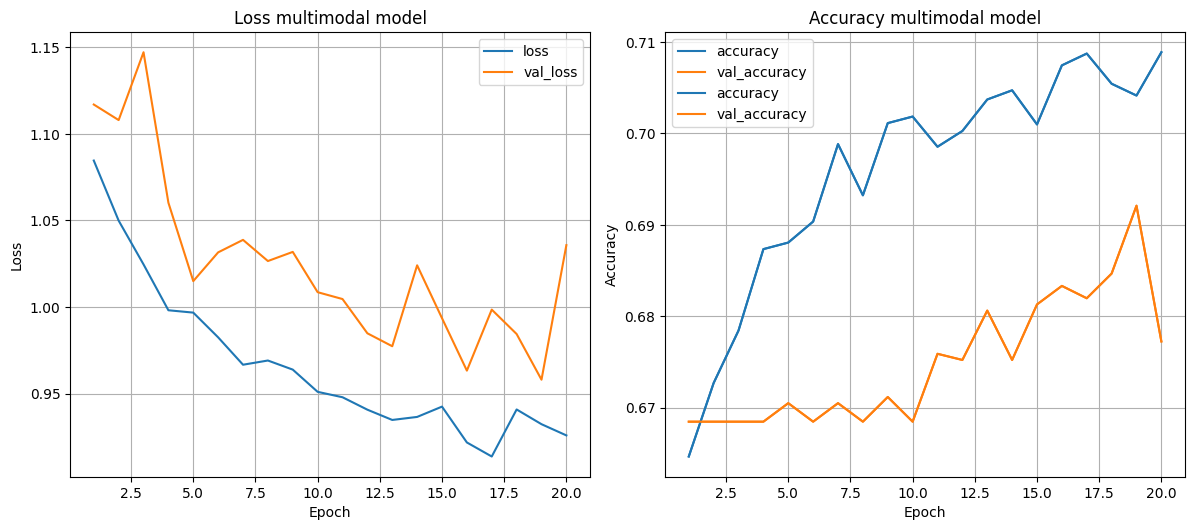


📘 **How to interpret these metrics for skin lesion classification:**

• **Loss curves**: Training ↓ but Validation ↑ = overfitting.
• **Accuracy**: Not enough alone with imbalanced data.
• **Precision**: High precision → few false positives.
• **Recall (KEY)**: High recall → fewer missed melanoma cases.
• **AUC**: >0.90 = strong classifier.


In [148]:
plot_history(history, "multimodal model")

In [149]:
model.save("multimodal_model.keras")